In [1]:
from google.colab import files
uploaded = files.upload()


Saving kucing.jpg to kucing.jpg


Nama file: kucing.jpg
Berhasil baca gambar
Tipe data: <class 'numpy.ndarray'>
Shape    : (450, 300, 3)
Dtype    : uint8

Artinya:
Tinggi = 450 piksel
Lebar = 300 piksel
Channel = 3 (BGR)

=== UKURAN GAMBAR ===

BGR:
(450, 300, 3)

RGB:
(450, 300, 3)

Grayscale:
(450, 300)

=== MATRIKS RGB (5x5) ===
[[[167 183 217]
  [167 183 217]
  [167 183 217]
  [167 183 217]
  [168 182 217]]

 [[167 183 217]
  [167 183 217]
  [167 183 217]
  [167 183 217]
  [167 182 217]]

 [[167 183 217]
  [167 183 217]
  [167 183 217]
  [167 183 217]
  [167 183 217]]

 [[165 184 217]
  [165 184 217]
  [166 184 217]
  [167 183 217]
  [167 183 217]]

 [[165 184 217]
  [165 184 217]
  [165 184 217]
  [165 184 217]
  [167 183 217]]]

=== MATRIKS GRAYSCALE (5x5) ===
[[182 182 182 182 182]
 [182 182 182 182 182]
 [182 182 182 182 182]
 [182 182 182 182 182]
 [182 182 182 182 182]]
Total piksel: 135000


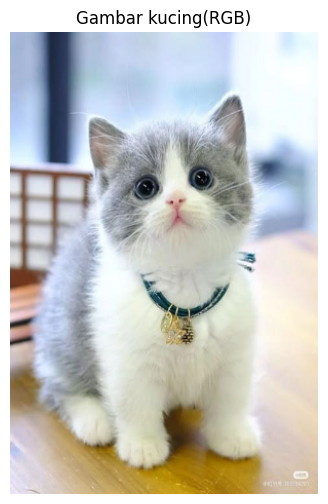

In [4]:
import cv2
import matplotlib.pyplot as plt

filename = list(uploaded.keys())[0]
print("Nama file:", filename)

img_bgr = cv2.imread(filename)

if img_bgr is None: # cek apakah gambar berhasil dibaca
  print("Error: gambar tidak ditemukan")
else:
  print("Berhasil baca gambar")

img_bgr = cv2.resize(img_bgr,(300,450))#Resize agar tidak terlalu besar

print("Tipe data:",type(img_bgr))#Cek tipe data
print("Shape    :",img_bgr.shape)
print("Dtype    :",img_bgr.dtype)

print()
print("Artinya:")
print(f"Tinggi = {img_bgr.shape[0]} piksel")
print(f"Lebar = {img_bgr.shape[1]} piksel")
print(f"Channel = {img_bgr.shape[2]} (BGR)")

img_rgb = cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB)#konversi BGR untuk matplotlib
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("\n=== UKURAN GAMBAR ===")
print("\nBGR:")
print(img_bgr.shape)

print("\nRGB:")
print(img_rgb.shape)

print("\nGrayscale:")
print(img_gray.shape)

print("\n=== MATRIKS RGB (5x5) ===")
rgb_sample = img_rgb[0:5, 0:5]
print(rgb_sample)

print("\n=== MATRIKS GRAYSCALE (5x5) ===")
gray_sample = img_gray[0:5, 0:5]
print(gray_sample)

print("Total piksel:", img_bgr.shape[0]*img_bgr.shape[1])

plt.figure(figsize=(4,6))#Tampilkan gambar
plt.imshow(img_rgb)
plt.title("Gambar kucing(RGB)")
plt.axis('off')
plt.show()

===MATRIKS f(x,y) - Area 8x8 Piksel ===
(Setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih))

[[189 179 171 166 165 158 148 153]
 [193 181 184 182 168 153 154 165]
 [192 185 186 178 162 153 162 168]
 [192 192 189 178 169 169 171 179]
 [201 197 195 192 189 187 191 196]
 [201 196 205 206 195 196 201 209]
 [210 207 210 205 196 201 209 211]
 [217 218 214 205 203 211 214 209]]

Contoh baca: f(200,100)= 189
Contoh baca: f(201,101)= 181


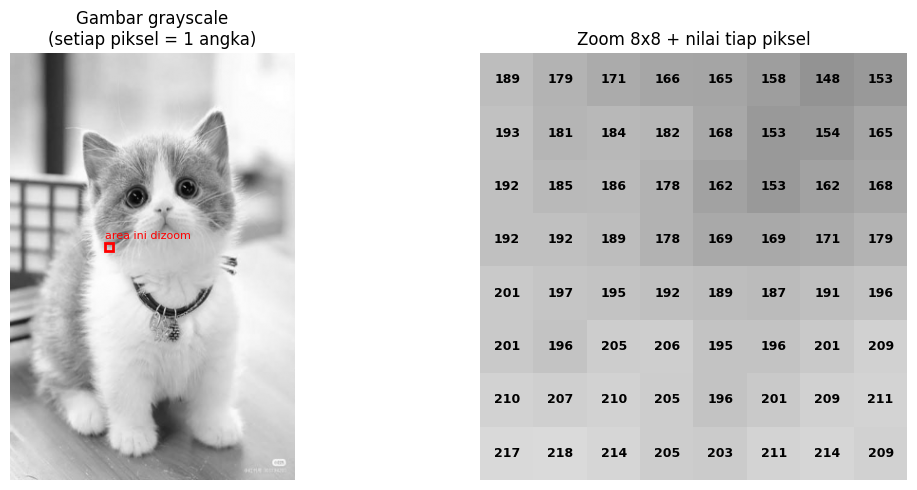

In [5]:
img_gray = cv2.cvtColor(img_bgr,cv2.COLOR_BGR2GRAY)#konversi ke grayscale
area_kecil = img_gray[200:208, 100:108]#ambil area kecil 8x8 piksel dari tengah gambar(area bulu kucing/objek)

print("===MATRIKS f(x,y) - Area 8x8 Piksel ===")
print("(Setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih))")
print()
print(area_kecil)

print()
print("Contoh baca:", "f(200,100)=",img_gray[200,100])
print("Contoh baca:", "f(201,101)=",img_gray[201,101])

fig,axes = plt.subplots(1,2, figsize=(12,5))#Tampilkan area kecil

axes[0].imshow(img_gray,cmap='gray',vmin=0, vmax=255)#Kiri:gambar grayscale penuh
axes[0].set_title("Gambar grayscale\n(setiap piksel = 1 angka)")
axes[0].axis('off')

import matplotlib.patches as patches #tanda area yang dizoom
rect = patches.Rectangle((100,200),8,8, linewidth =2, edgecolor ='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(100,195, "area ini dizoom", color='red', fontsize=8)

axes[1].imshow(area_kecil, cmap='gray', vmin=0,vmax=255)# Kanan tampilan area kecil + angka

for i in range(8):
  for j in range(8):
    nilai = area_kecil[i,j]
    warna_teks = 'white' if nilai < 128 else 'black'
    axes[1].text(j,i, str(nilai), ha='center', va='center', fontsize=9, color=warna_teks, fontweight='bold')

axes[1].set_title("Zoom 8x8 + nilai tiap piksel")
axes[1].axis('off')

plt.tight_layout()
plt.show()